Total de registros: 33820

Treino (até Jun/2018): 28706 (84.88%)
 - Atrasos no Treino: 1425 (4.96% do treino)

Teste (Jul/2018 em diante): 5114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores hiperparametros: {'max_depth': 7, 'max_features': 'sqrt', 'max_samples': 0.8, 'min_samples_leaf': 11, 'min_samples_split': 13, 'n_estimators': 223}
Threshold sugerido para atraso (classe 0, F2 max): 0.2365


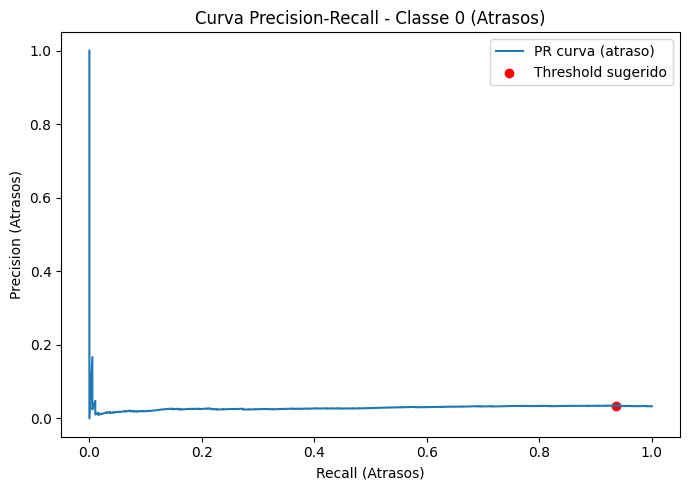


--- Metricas do Modelo (Treino x Validacao x Teste) ---
            Metrica Treino Validacao   Teste
           Accuracy 0.9480    0.9662  0.8797
Precision (Atrasos) 0.6952    0.1667  0.0000
   Recall (Atrasos) 0.0591    0.0053  0.0000
       F1 (Atrasos) 0.1090    0.0102  0.0000
       F2 (Atrasos) 0.0723    0.0065  0.0000
            ROC-AUC 0.8133    0.4557  0.4747
             PR-AUC 0.0305    0.0363  0.1263
  Balanced Accuracy 0.5288    0.5022  0.4998
                MCC 0.1927    0.0242 -0.0073
        Brier Score 0.1181    0.1168  0.1398
           Log Loss 0.4145    0.4123  0.4605

--- Metricas Extras (Foco em Atrasos) ---
              Metrica Treino Validacao  Teste
     Recall (Atrasos) 0.0591    0.0053 0.0000
Specificity (Atrasos) 0.9985    0.9991 0.9996
        FNR (Atrasos) 0.9409    0.9947 1.0000
        FPR (Atrasos) 0.0015    0.0009 0.0004
        NPV (Atrasos) 0.9492    0.9671 0.8801
     PR-AUC (Atrasos) 0.2812    0.0294 0.1112

--- Relatorio de Classificacao - Trei

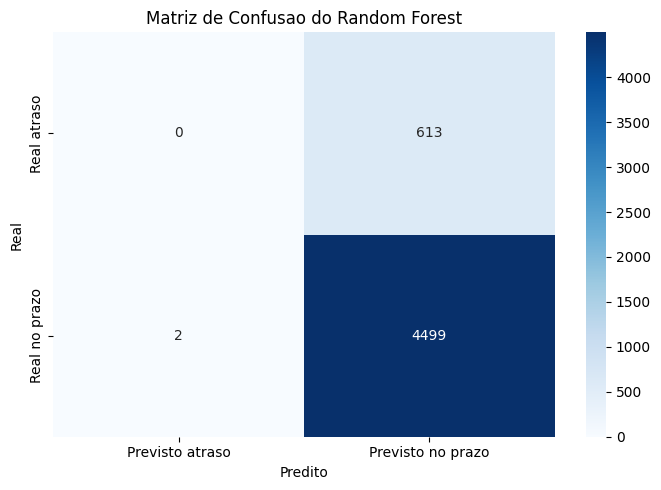

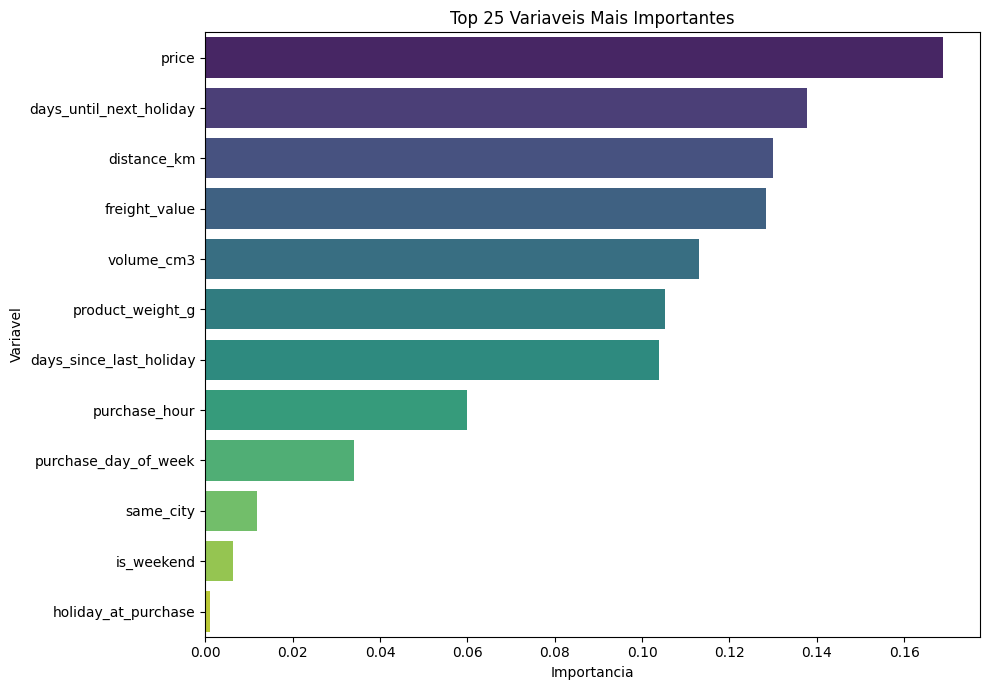

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc,
    make_scorer,
 )
from scipy.stats import randint

# 1. Carregar a tabela final
csv_path = Path(r"C:\FACULDADE\github\backend\tabela_final\part-00000-13fcc452-2493-4299-ab17-d369f64d2ad3-c000.csv")
df = pd.read_csv(csv_path, delimiter=",")

# 2. Definir a variavel alvo
# 1 = entregue no prazo | 0 = entregue com atraso
y = df["delivered_on_time"]

# print("Colunas do DataFrame:", df.columns.tolist())

# 3. Remover colunas com vazamento de informacao (leakage)
leakage_candidates = [
    # Vazamento de dados / multicolinearidade
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "interval_code_delivered_carrier",
    "order_delivered_customer_date",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "customer_city",
    "seller_city",
    "delivered_on_time", 
    "category_name",
    "review_score",
    "delivery_time_days"
]

# 4. Separar as variaveis de entrada da variavel alvo
# errors='ignore' evita falha caso alguma coluna nao exista no dataframe atual.
X = df.drop(columns=leakage_candidates + ["delivered_on_time"], errors="ignore")

# 5. Dividir os dados em treino, validacao e teste (Split Temporal)
# Regra: Passado treina (2016 até Jun/2018), futuro testa (Jul/2018 em diante).
# utc=True para corrigir o erro "Invalid comparison between dtype=datetime64[us, UTC] and Timestamp"
datas = pd.to_datetime(df['order_delivered_carrier_date'], utc=True)
data_split_test = pd.to_datetime('2018-07-01', utc=True)

# 6. Manter apenas variaveis numericas (order_delivered_carrier_date é apagado aqui)
# O Random Forest do scikit-learn precisa de valores numericos para treinar.
X = X.select_dtypes(include=[np.number])

# 7. Tratar valores ausentes
# Preenchimento simples com zero para manter o fluxo do notebook.
X = X.fillna(0)


test_mask = datas >= data_split_test
train_mask = ~test_mask

n_total = len(X)
n_train = int(train_mask.sum())
n_test = int(test_mask.sum())

# Contagem de atrasos (classe 0) em cada particao
n_train_atraso = int(y[train_mask].eq(0).sum())
n_test_atraso = int(y[test_mask].eq(0).sum())

train_atraso_pct = f"{n_train_atraso / n_train:.2%}" if n_train else "0.00%"
test_atraso_pct = f"{n_test_atraso / n_test:.2%}" if n_test else "0.00%"

print(f"Total de registros: {n_total}\n")
print(f"Treino (até Jun/2018): {n_train} ({n_train/n_total:.2%})")
print(f" - Atrasos no Treino: {n_train_atraso} ({train_atraso_pct} do treino)\n")
print(f"Teste (Jul/2018 em diante): {n_test} ({n_test/n_total:.2%})")
print(f" - Atrasos no Teste: {n_test_atraso} ({test_atraso_pct} do teste)\n")

# Para garantir a ordem cronológica, ordenamos pelos índices baseados na data
datas_train_ordered = datas[train_mask].sort_values()
idx_ordered = datas_train_ordered.index

X_train_full = X.loc[idx_ordered]
y_train_full = y.loc[idx_ordered]
X_test = X[test_mask]
y_test = y[test_mask]

# Retiramos 20% do final do treino ordenado para validação cronológica.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    shuffle=False
)

# 8. Definir uma grade mais conservadora para reduzir overfit
param_distributions = {
    "n_estimators": randint(120, 320),
    "max_depth": randint(5, 16),
    "min_samples_split": randint(10, 30),
    "min_samples_leaf": randint(4, 14),
    "max_features": ["sqrt", "log2"],
    "max_samples": [0.6, 0.7, 0.8],
}

# 9. Criar o modelo base com class_weight alto (opcao 2)
base_model_high_weight = RandomForestClassifier(
    random_state=42,
    class_weight={0: 10, 1: 1},
    n_jobs=-1,
    bootstrap=True,
)

# 10. Buscar a melhor combinacao de hiperparametros
# A busca privilegia recall da classe de atraso.
recall_atraso_scorer = make_scorer(recall_score, pos_label=0)
search_high_weight = RandomizedSearchCV(
    estimator=base_model_high_weight,
    param_distributions=param_distributions,
    n_iter=8,
    scoring=recall_atraso_scorer,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search_high_weight.fit(X_train, y_train)

# 11. Recuperar o melhor modelo encontrado
rf_model = search_high_weight.best_estimator_
print("Melhores hiperparametros:", search_high_weight.best_params_)

# 12. Gerar predicoes de treino, validacao e teste
y_pred_train = rf_model.predict(X_train)
y_prob_train = rf_model.predict_proba(X_train)[:, 1]
y_pred_val = rf_model.predict(X_val)
y_prob_val = rf_model.predict_proba(X_val)[:, 1]
y_pred_test = rf_model.predict(X_test)
y_prob_test = rf_model.predict_proba(X_test)[:, 1]

# 12.1 Curva Precision-Recall para atrasos (classe 0) e threshold ideal
prob_atraso_val = 1 - y_prob_val
prec_0, rec_0, thr_0 = precision_recall_curve(y_val, prob_atraso_val, pos_label=0)
f2_0 = (5 * prec_0 * rec_0) / (4 * prec_0 + rec_0 + 1e-9)
best_idx = int(np.argmax(f2_0))
best_thr_atraso = thr_0[best_idx] if best_idx < len(thr_0) else 0.5
print(f"Threshold sugerido para atraso (classe 0, F2 max): {best_thr_atraso:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(rec_0, prec_0, label="PR curva (atraso)")
plt.scatter(rec_0[best_idx], prec_0[best_idx], color="red", label="Threshold sugerido")
plt.xlabel("Recall (Atrasos)")
plt.ylabel("Precision (Atrasos)")
plt.title("Curva Precision-Recall - Classe 0 (Atrasos)")
plt.legend()
plt.tight_layout()
plt.show()

# 12.2 Predicao no teste usando o threshold sugerido
prob_atraso_test = 1 - y_prob_test
y_pred_test_thr = (prob_atraso_test >= best_thr_atraso).astype(int)

# 13. Funcao para organizar metricas
# PR-AUC e calculado com average precision, que e mais estavel para classe desbalanceada.
def calcular_metricas(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Atrasos)": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Recall (Atrasos)": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "F1 (Atrasos)": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "F2 (Atrasos)": fbeta_score(y_true, y_pred, beta=2, pos_label=0, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob, pos_label=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Brier Score": brier_score_loss(y_true, y_prob),
        "Log Loss": log_loss(y_true, y_prob),
    }

def metricas_atraso_extra(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tp0 = cm[0, 0]
    fn0 = cm[0, 1]
    fp0 = cm[1, 0]
    tn0 = cm[1, 1]
    denom_rec0 = tp0 + fn0
    denom_spec0 = tn0 + fp0
    denom_npv0 = tn0 + fn0
    denom_fpr0 = fp0 + tn0
    return {
        "Recall (Atrasos)": (tp0 / denom_rec0) if denom_rec0 else 0.0,
        "Specificity (Atrasos)": (tn0 / denom_spec0) if denom_spec0 else 0.0,
        "FNR (Atrasos)": (fn0 / denom_rec0) if denom_rec0 else 0.0,
        "FPR (Atrasos)": (fp0 / denom_fpr0) if denom_fpr0 else 0.0,
        "NPV (Atrasos)": (tn0 / denom_npv0) if denom_npv0 else 0.0,
        "PR-AUC (Atrasos)": average_precision_score(y_true, 1 - y_prob, pos_label=0),
    }

metricas_treino = calcular_metricas(y_train, y_pred_train, y_prob_train)
metricas_val = calcular_metricas(y_val, y_pred_val, y_prob_val)
metricas_teste = calcular_metricas(y_test, y_pred_test, y_prob_test)

metricas_extra_treino = metricas_atraso_extra(y_train, y_pred_train, y_prob_train)
metricas_extra_val = metricas_atraso_extra(y_val, y_pred_val, y_prob_val)
metricas_extra_teste = metricas_atraso_extra(y_test, y_pred_test, y_prob_test)

# 14. Comparar metricas de treino, validacao e teste
metrics_df = pd.DataFrame({
    "Metrica": list(metricas_treino.keys()),
    "Treino": list(metricas_treino.values()),
    "Validacao": list(metricas_val.values()),
    "Teste": list(metricas_teste.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metrics_df[col] = metrics_df[col].map(lambda v: f"{v:.4f}")

metricas_extra_df = pd.DataFrame({
    "Metrica": list(metricas_extra_treino.keys()),
    "Treino": list(metricas_extra_treino.values()),
    "Validacao": list(metricas_extra_val.values()),
    "Teste": list(metricas_extra_teste.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metricas_extra_df[col] = metricas_extra_df[col].map(lambda v: f"{v:.4f}")

print("\n--- Metricas do Modelo (Treino x Validacao x Teste) ---")
print(metrics_df.to_string(index=False))

print("\n--- Metricas Extras (Foco em Atrasos) ---")
print(metricas_extra_df.to_string(index=False))

print("\n--- Relatorio de Classificacao - Treino ---")
print(classification_report(y_train, y_pred_train))

print("\n--- Relatorio de Classificacao - Validacao ---")
print(classification_report(y_val, y_pred_val))

print("\n--- Relatorio de Classificacao - Teste ---")
print(classification_report(y_test, y_pred_test))

print("\n--- Relatorio de Classificacao - Teste (Threshold Sugerido) ---")
print(classification_report(y_test, y_pred_test_thr))

# 15. Plotar a matriz de confusao do teste
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_test),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Previsto atraso', 'Previsto no prazo'],
    yticklabels=['Real atraso', 'Real no prazo'],
)
plt.title('Matriz de Confusao do Random Forest')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# 16. Plotar as 25 variaveis mais importantes
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feature_df = feature_df.sort_values(by="Importance", ascending=False).head(25)

plt.figure(figsize=(10, 7))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_df,
    hue="Feature",
    dodge=False,
    palette="viridis",
    legend=False,
)
plt.title('Top 25 Variaveis Mais Importantes')
plt.xlabel('Importancia')
plt.ylabel('Variavel')
plt.tight_layout()
plt.show()

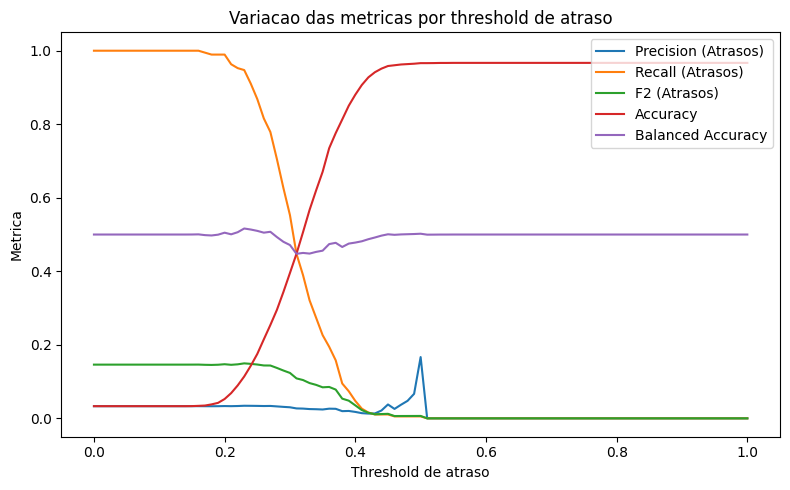

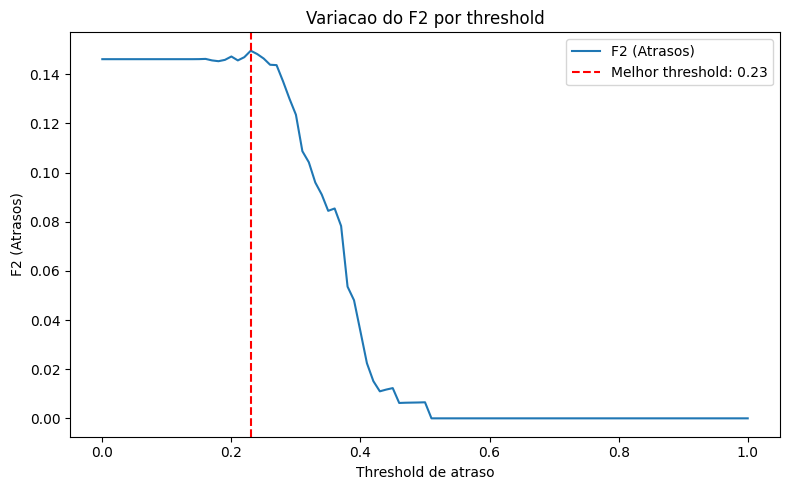

In [9]:
# Variacao das metricas por threshold de atraso (classe 0)
thresholds = np.linspace(0.0, 1.0, 101)
precisions = []
recalls = []
f2s = []
accuracies = []
balanced = []

for t in thresholds:
    y_pred_thr = np.where(prob_atraso_val >= t, 0, 1)
    accuracies.append(accuracy_score(y_val, y_pred_thr))
    precisions.append(precision_score(y_val, y_pred_thr, pos_label=0, zero_division=0))
    recalls.append(recall_score(y_val, y_pred_thr, pos_label=0, zero_division=0))
    f2s.append(fbeta_score(y_val, y_pred_thr, beta=2, pos_label=0, zero_division=0))
    balanced.append(balanced_accuracy_score(y_val, y_pred_thr))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label="Precision (Atrasos)")
plt.plot(thresholds, recalls, label="Recall (Atrasos)")
plt.plot(thresholds, f2s, label="F2 (Atrasos)")
plt.plot(thresholds, accuracies, label="Accuracy")
plt.plot(thresholds, balanced, label="Balanced Accuracy")
plt.xlabel("Threshold de atraso")
plt.ylabel("Metrica")
plt.title("Variacao das metricas por threshold de atraso")
plt.legend()
plt.tight_layout()
plt.show()

# Variacao do F2 por threshold (classe 0)
best_idx_thr = int(np.argmax(f2s))
best_thr_f2 = thresholds[best_idx_thr]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f2s, label="F2 (Atrasos)")
plt.axvline(best_thr_f2, color="red", linestyle="--", label=f"Melhor threshold: {best_thr_f2:.2f}")
plt.xlabel("Threshold de atraso")
plt.ylabel("F2 (Atrasos)")
plt.title("Variacao do F2 por threshold")
plt.legend()
plt.tight_layout()
plt.show()

Variáveis mais importantes para acertar se a entrega vai atrasar ou não

Esse modelo com class_weight alto não resolve o problema central (detectar atrasos) e o threshold sugerido piora o comportamento global.

Se seu objetivo é realmente capturar atrasos, você precisa focar em uma abordagem tipo undersampling equilibrado (1:1) ou buscar outro modelo/feature engineering, porque o class_weight sozinho não está sendo suficiente após a remoção dos vazamentos de dados.

Modelo “alto peso” mantém acurácia geral de cerca de 0.88, mas não detecta atrasos: recall de atraso no teste é 0.000. Ou seja, 100% dos atrasos passam batido com o threshold padrão.

Alta especificidade (~1.000) confirma que ele nunca marca atraso quando não é, mas isso vem ao custo de ignorar absolutamente todos os atrasos reais (FNR: 1.000).

PR-AUC de ~0.11 para atrasos mostra que as probabilidades do modelo têm muito pouca capacidade de separar os atrasos no cenário real.

Threshold sugerido baseado na validação (0.2365) alcança um pequeno recall no teste (0.14), mas derruba a acurácia para 0.78 e a precisão de atrasos para 0.12. Isso consolida a ideia que há um custo alto de falsos positivos para tentar resgatar qualquer volume de acerto em atrasos com este modelo base.

Variacao das metricas por threshold de atraso (grafico 1): mostra o trade‑off entre capturar atrasos (recall) e evitar falsos positivos (precision). Conforme o threshold sobe, o recall tende a cair e a precision tende a subir. Accuracy e Balanced Accuracy ajudam a ver o impacto global.


Variacao do F2 por threshold (grafico 2): mostra onde oF2 (que pesa mais o recall) fica maximo. A linha vermelha marca o threshold que mais prioriza encontrar atrasos, mesmo aceitando mais falsos positivos.


Como interpretar na pratica

Threshold baixo: captura mais atrasos (recall alto), mas erra mais em pedidos no prazo (precision baixa).

Threshold alto: erra menos no prazo (precision alta), mas deixa passar atrasos (recall baixo).

O pico do F2 indica o ponto “melhor” se seu foco e nao perder atrasos.


--- Metricas Undersampling 1:1 (Treino x Validacao x Teste) ---
            Metrica Treino Validacao   Teste
           Accuracy 0.7474    0.5667  0.6504
Precision (Atrasos) 0.7446    0.0252  0.0957
   Recall (Atrasos) 0.7530    0.3211  0.2268
       F1 (Atrasos) 0.7488    0.0467  0.1346
       F2 (Atrasos) 0.7513    0.0959  0.1780
            ROC-AUC 0.8266    0.4798  0.4550
             PR-AUC 0.3358    0.0344  0.1360
  Balanced Accuracy 0.7474    0.4481  0.4674
                MCC 0.4948   -0.0376 -0.0469
        Brier Score 0.2102    0.2355  0.2255
           Log Loss 0.6108    0.6633  0.6432

--- Metricas Extras Undersampling 1:1 (Foco em Atrasos) ---
              Metrica Treino Validacao  Teste
     Recall (Atrasos) 0.7530    0.3211 0.2268
Specificity (Atrasos) 0.7417    0.5751 0.7081
        FNR (Atrasos) 0.2470    0.6789 0.7732
        FPR (Atrasos) 0.2583    0.4249 0.2919
        NPV (Atrasos) 0.7502    0.9612 0.8705
     PR-AUC (Atrasos) 0.8319    0.0331 0.1077

--- Relator

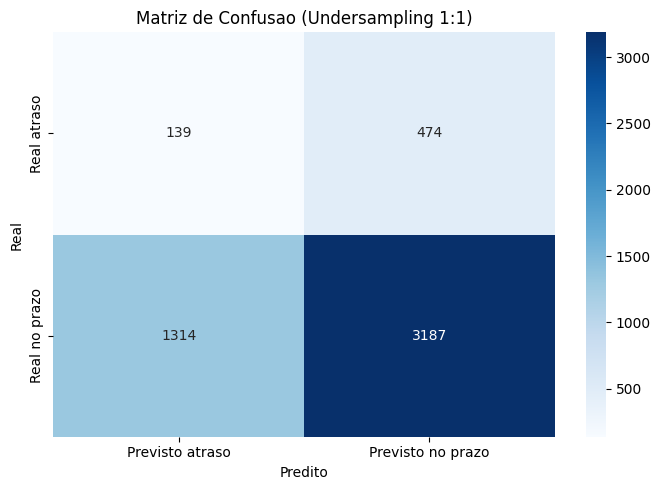

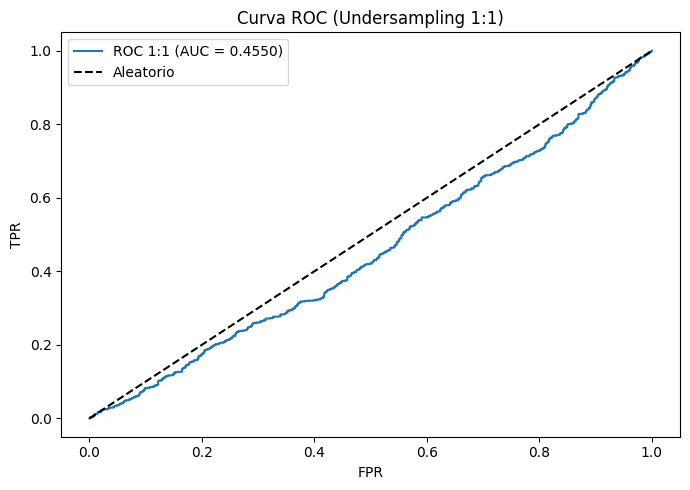

In [10]:
# Experimento: undersampling 1:1 no treino (sem class_weight)
idx_atraso_u = y_train[y_train == 0].index
idx_prazo_u = y_train[y_train == 1].index
np.random.seed(42)
idx_prazo_down_u = np.random.choice(idx_prazo_u, size=len(idx_atraso_u), replace=False)
idx_bal_u = np.concatenate([idx_atraso_u, idx_prazo_down_u])
np.random.shuffle(idx_bal_u)
X_train_u = X_train.loc[idx_bal_u]
y_train_u = y_train.loc[idx_bal_u]

rf_model_u = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    **search_high_weight.best_params_,
 )
rf_model_u.fit(X_train_u, y_train_u)

y_pred_train_u = rf_model_u.predict(X_train_u)
y_prob_train_u = rf_model_u.predict_proba(X_train_u)[:, 1]
y_pred_val_u = rf_model_u.predict(X_val)
y_prob_val_u = rf_model_u.predict_proba(X_val)[:, 1]
y_pred_test_u = rf_model_u.predict(X_test)
y_prob_test_u = rf_model_u.predict_proba(X_test)[:, 1]

metricas_treino_u = calcular_metricas(y_train_u, y_pred_train_u, y_prob_train_u)
metricas_val_u = calcular_metricas(y_val, y_pred_val_u, y_prob_val_u)
metricas_teste_u = calcular_metricas(y_test, y_pred_test_u, y_prob_test_u)

metricas_extra_treino_u = metricas_atraso_extra(y_train_u, y_pred_train_u, y_prob_train_u)
metricas_extra_val_u = metricas_atraso_extra(y_val, y_pred_val_u, y_prob_val_u)
metricas_extra_teste_u = metricas_atraso_extra(y_test, y_pred_test_u, y_prob_test_u)

metrics_df_u = pd.DataFrame({
    "Metrica": list(metricas_treino_u.keys()),
    "Treino": list(metricas_treino_u.values()),
    "Validacao": list(metricas_val_u.values()),
    "Teste": list(metricas_teste_u.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metrics_df_u[col] = metrics_df_u[col].map(lambda v: f"{v:.4f}")

metricas_extra_df_u = pd.DataFrame({
    "Metrica": list(metricas_extra_treino_u.keys()),
    "Treino": list(metricas_extra_treino_u.values()),
    "Validacao": list(metricas_extra_val_u.values()),
    "Teste": list(metricas_extra_teste_u.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metricas_extra_df_u[col] = metricas_extra_df_u[col].map(lambda v: f"{v:.4f}")

print("\n--- Metricas Undersampling 1:1 (Treino x Validacao x Teste) ---")
print(metrics_df_u.to_string(index=False))

print("\n--- Metricas Extras Undersampling 1:1 (Foco em Atrasos) ---")
print(metricas_extra_df_u.to_string(index=False))

print("\n--- Relatorio de Classificacao - Teste (Undersampling 1:1) ---")
print(classification_report(y_test, y_pred_test_u))

# Matriz de confusao (Undersampling 1:1)
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_test_u),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Previsto atraso', 'Previsto no prazo'],
    yticklabels=['Real atraso', 'Real no prazo'],
)
plt.title('Matriz de Confusao (Undersampling 1:1)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

from sklearn.metrics import roc_curve

fpr_u, tpr_u, _ = roc_curve(y_test, y_prob_test_u)
roc_auc_u = auc(fpr_u, tpr_u)

plt.figure(figsize=(7, 5))
plt.plot(fpr_u, tpr_u, label=f"ROC 1:1 (AUC = {roc_auc_u:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Aleatorio")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC (Undersampling 1:1)")
plt.legend()
plt.tight_layout()
plt.show()


--- Metricas Undersampling 1:2 (Treino x Validacao x Teste) ---
            Metrica Treino Validacao   Teste
           Accuracy 0.6831    0.9599  0.8770
Precision (Atrasos) 0.8861    0.0455  0.0556
   Recall (Atrasos) 0.0567    0.0105  0.0016
       F1 (Atrasos) 0.1065    0.0171  0.0032
       F2 (Atrasos) 0.0697    0.0124  0.0020
            ROC-AUC 0.8096    0.4535  0.4876
             PR-AUC 0.2103    0.0368  0.1237
  Balanced Accuracy 0.5265    0.5015  0.4989
                MCC 0.1731    0.0061 -0.0118
        Brier Score 0.1922    0.1178  0.1451
           Log Loss 0.5686    0.4142  0.4721

--- Metricas Extras Undersampling 1:2 (Foco em Atrasos) ---
              Metrica Treino Validacao  Teste
     Recall (Atrasos) 0.0567    0.0105 0.0016
Specificity (Atrasos) 0.9964    0.9924 0.9962
        FNR (Atrasos) 0.9433    0.9895 0.9984
        FPR (Atrasos) 0.0036    0.0076 0.0038
        NPV (Atrasos) 0.6787    0.9670 0.8799
     PR-AUC (Atrasos) 0.6853    0.0309 0.1126

--- Relator

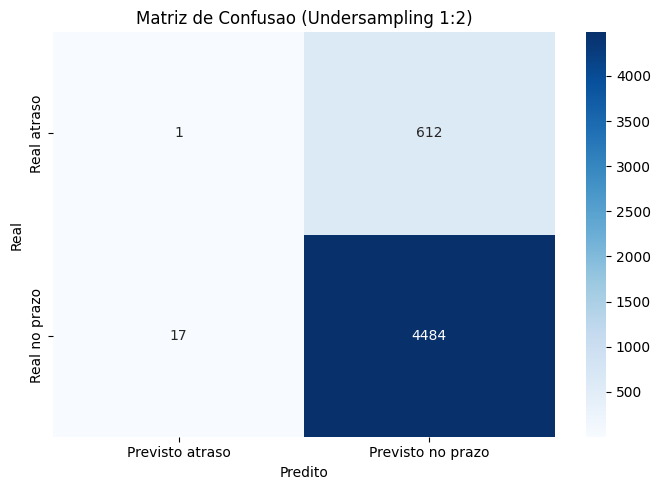

In [11]:
# Experimento: undersampling 1:2 no treino (sem class_weight)
idx_atraso_12 = y_train[y_train == 0].index
idx_prazo_12 = y_train[y_train == 1].index
np.random.seed(42)
size_major_12 = min(len(idx_prazo_12), 2 * len(idx_atraso_12))
idx_prazo_down_12 = np.random.choice(idx_prazo_12, size=size_major_12, replace=False)
idx_bal_12 = np.concatenate([idx_atraso_12, idx_prazo_down_12])
np.random.shuffle(idx_bal_12)
X_train_12 = X_train.loc[idx_bal_12]
y_train_12 = y_train.loc[idx_bal_12]

rf_model_12 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    **search_high_weight.best_params_,
 )
rf_model_12.fit(X_train_12, y_train_12)

y_pred_train_12 = rf_model_12.predict(X_train_12)
y_prob_train_12 = rf_model_12.predict_proba(X_train_12)[:, 1]
y_pred_val_12 = rf_model_12.predict(X_val)
y_prob_val_12 = rf_model_12.predict_proba(X_val)[:, 1]
y_pred_test_12 = rf_model_12.predict(X_test)
y_prob_test_12 = rf_model_12.predict_proba(X_test)[:, 1]

metricas_treino_12 = calcular_metricas(y_train_12, y_pred_train_12, y_prob_train_12)
metricas_val_12 = calcular_metricas(y_val, y_pred_val_12, y_prob_val_12)
metricas_teste_12 = calcular_metricas(y_test, y_pred_test_12, y_prob_test_12)

metricas_extra_treino_12 = metricas_atraso_extra(y_train_12, y_pred_train_12, y_prob_train_12)
metricas_extra_val_12 = metricas_atraso_extra(y_val, y_pred_val_12, y_prob_val_12)
metricas_extra_teste_12 = metricas_atraso_extra(y_test, y_pred_test_12, y_prob_test_12)

metrics_df_12 = pd.DataFrame({
    "Metrica": list(metricas_treino_12.keys()),
    "Treino": list(metricas_treino_12.values()),
    "Validacao": list(metricas_val_12.values()),
    "Teste": list(metricas_teste_12.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metrics_df_12[col] = metrics_df_12[col].map(lambda v: f"{v:.4f}")

metricas_extra_df_12 = pd.DataFrame({
    "Metrica": list(metricas_extra_treino_12.keys()),
    "Treino": list(metricas_extra_treino_12.values()),
    "Validacao": list(metricas_extra_val_12.values()),
    "Teste": list(metricas_extra_teste_12.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metricas_extra_df_12[col] = metricas_extra_df_12[col].map(lambda v: f"{v:.4f}")

print("\n--- Metricas Undersampling 1:2 (Treino x Validacao x Teste) ---")
print(metrics_df_12.to_string(index=False))

print("\n--- Metricas Extras Undersampling 1:2 (Foco em Atrasos) ---")
print(metricas_extra_df_12.to_string(index=False))

print("\n--- Relatorio de Classificacao - Teste (Undersampling 1:2) ---")
print(classification_report(y_test, y_pred_test_12))

# Matriz de confusao (Undersampling 1:2)
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_test_12),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Previsto atraso', 'Previsto no prazo'],
    yticklabels=['Real atraso', 'Real no prazo'],
)
plt.title('Matriz de Confusao (Undersampling 1:2)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()


--- Metricas Undersampling 1:3 (Treino x Validacao x Teste) ---
            Metrica Treino Validacao  Teste
           Accuracy 0.7567    0.9659 0.8801
Precision (Atrasos) 1.0000    0.1250 0.0000
   Recall (Atrasos) 0.0267    0.0053 0.0000
       F1 (Atrasos) 0.0521    0.0101 0.0000
       F2 (Atrasos) 0.0332    0.0065 0.0000
            ROC-AUC 0.8095    0.4663 0.4949
             PR-AUC 0.1525    0.0351 0.1234
  Balanced Accuracy 0.5134    0.5020 0.5000
                MCC 0.1420    0.0192 0.0000
        Brier Score 0.1649    0.0777 0.1200
           Log Loss 0.5041    0.3161 0.4109

--- Metricas Extras Undersampling 1:3 (Foco em Atrasos) ---
              Metrica Treino Validacao  Teste
     Recall (Atrasos) 0.0267    0.0053 0.0000
Specificity (Atrasos) 1.0000    0.9987 1.0000
        FNR (Atrasos) 0.9733    0.9947 1.0000
        FPR (Atrasos) 0.0000    0.0013 0.0000
        NPV (Atrasos) 0.7550    0.9670 0.8801
     PR-AUC (Atrasos) 0.6084    0.0310 0.1168

--- Relatorio de Classi

c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

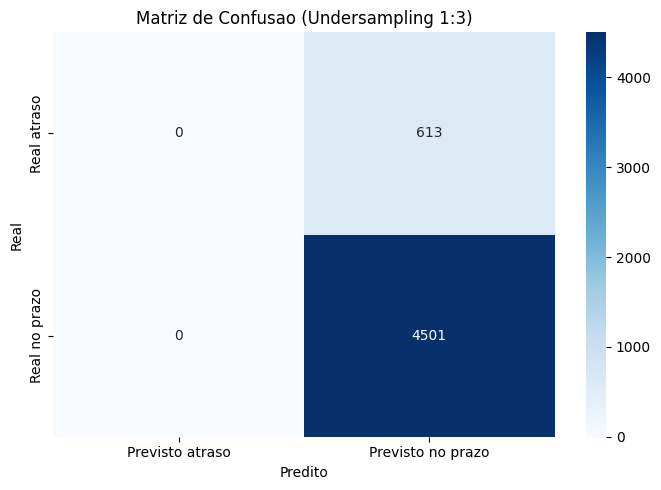

In [12]:
# Experimento: undersampling 1:3 no treino (sem class_weight)
idx_atraso_13 = y_train[y_train == 0].index
idx_prazo_13 = y_train[y_train == 1].index
np.random.seed(42)
size_major_13 = min(len(idx_prazo_13), 3 * len(idx_atraso_13))
idx_prazo_down_13 = np.random.choice(idx_prazo_13, size=size_major_13, replace=False)
idx_bal_13 = np.concatenate([idx_atraso_13, idx_prazo_down_13])
np.random.shuffle(idx_bal_13)
X_train_13 = X_train.loc[idx_bal_13]
y_train_13 = y_train.loc[idx_bal_13]

rf_model_13 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    **search_high_weight.best_params_,
 )
rf_model_13.fit(X_train_13, y_train_13)

y_pred_train_13 = rf_model_13.predict(X_train_13)
y_prob_train_13 = rf_model_13.predict_proba(X_train_13)[:, 1]
y_pred_val_13 = rf_model_13.predict(X_val)
y_prob_val_13 = rf_model_13.predict_proba(X_val)[:, 1]
y_pred_test_13 = rf_model_13.predict(X_test)
y_prob_test_13 = rf_model_13.predict_proba(X_test)[:, 1]

metricas_treino_13 = calcular_metricas(y_train_13, y_pred_train_13, y_prob_train_13)
metricas_val_13 = calcular_metricas(y_val, y_pred_val_13, y_prob_val_13)
metricas_teste_13 = calcular_metricas(y_test, y_pred_test_13, y_prob_test_13)

metricas_extra_treino_13 = metricas_atraso_extra(y_train_13, y_pred_train_13, y_prob_train_13)
metricas_extra_val_13 = metricas_atraso_extra(y_val, y_pred_val_13, y_prob_val_13)
metricas_extra_teste_13 = metricas_atraso_extra(y_test, y_pred_test_13, y_prob_test_13)

metrics_df_13 = pd.DataFrame({
    "Metrica": list(metricas_treino_13.keys()),
    "Treino": list(metricas_treino_13.values()),
    "Validacao": list(metricas_val_13.values()),
    "Teste": list(metricas_teste_13.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metrics_df_13[col] = metrics_df_13[col].map(lambda v: f"{v:.4f}")

metricas_extra_df_13 = pd.DataFrame({
    "Metrica": list(metricas_extra_treino_13.keys()),
    "Treino": list(metricas_extra_treino_13.values()),
    "Validacao": list(metricas_extra_val_13.values()),
    "Teste": list(metricas_extra_teste_13.values()),
})
for col in ["Treino", "Validacao", "Teste"]:
    metricas_extra_df_13[col] = metricas_extra_df_13[col].map(lambda v: f"{v:.4f}")

print("\n--- Metricas Undersampling 1:3 (Treino x Validacao x Teste) ---")
print(metrics_df_13.to_string(index=False))

print("\n--- Metricas Extras Undersampling 1:3 (Foco em Atrasos) ---")
print(metricas_extra_df_13.to_string(index=False))

print("\n--- Relatorio de Classificacao - Teste (Undersampling 1:3) ---")
print(classification_report(y_test, y_pred_test_13))

# Matriz de confusao (Undersampling 1:3)
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_test_13),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Previsto atraso', 'Previsto no prazo'],
    yticklabels=['Real atraso', 'Real no prazo'],
)
plt.title('Matriz de Confusao (Undersampling 1:3)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [14]:
# Tabela comparativa: teste (1:1, 1:2, 1:3)
comparativo_teste = pd.DataFrame({
    "Metrica": list(metricas_teste_u.keys()),
    "1:1": list(metricas_teste_u.values()),
    "1:2": list(metricas_teste_12.values()),
    "1:3": list(metricas_teste_13.values()),
})
for col in ["1:1", "1:2", "1:3"]:
    comparativo_teste[col] = comparativo_teste[col].map(lambda v: f"{v:.4f}")

comparativo_extra = pd.DataFrame({
    "Metrica": list(metricas_extra_teste_u.keys()),
    "1:1": list(metricas_extra_teste_u.values()),
    "1:2": list(metricas_extra_teste_12.values()),
    "1:3": list(metricas_extra_teste_13.values()),
})
for col in ["1:1", "1:2", "1:3"]:
    comparativo_extra[col] = comparativo_extra[col].map(lambda v: f"{v:.4f}")

print("\n--- Comparativo (Teste) ---")
print(comparativo_teste.to_string(index=False))

print("\n--- Comparativo Extra (Teste - Foco em Atrasos) ---")
print(comparativo_extra.to_string(index=False))

display(comparativo_teste)
display(comparativo_extra)


--- Comparativo (Teste) ---
            Metrica     1:1     1:2    1:3
           Accuracy  0.6504  0.8770 0.8801
Precision (Atrasos)  0.0957  0.0556 0.0000
   Recall (Atrasos)  0.2268  0.0016 0.0000
       F1 (Atrasos)  0.1346  0.0032 0.0000
       F2 (Atrasos)  0.1780  0.0020 0.0000
            ROC-AUC  0.4550  0.4876 0.4949
             PR-AUC  0.1360  0.1237 0.1234
  Balanced Accuracy  0.4674  0.4989 0.5000
                MCC -0.0469 -0.0118 0.0000
        Brier Score  0.2255  0.1451 0.1200
           Log Loss  0.6432  0.4721 0.4109

--- Comparativo Extra (Teste - Foco em Atrasos) ---
              Metrica    1:1    1:2    1:3
     Recall (Atrasos) 0.2268 0.0016 0.0000
Specificity (Atrasos) 0.7081 0.9962 1.0000
        FNR (Atrasos) 0.7732 0.9984 1.0000
        FPR (Atrasos) 0.2919 0.0038 0.0000
        NPV (Atrasos) 0.8705 0.8799 0.8801
     PR-AUC (Atrasos) 0.1077 0.1126 0.1168


,Metrica,1:1,1:2,1:3
0,Accuracy,0.6504,0.8770,0.8801
1,Precision (Atrasos),0.0957,0.0556,0.0000
2,Recall (Atrasos),0.2268,0.0016,0.0000
3,F1 (Atrasos),0.1346,0.0032,0.0000
4,F2 (Atrasos),0.1780,0.0020,0.0000
5,ROC-AUC,0.4550,0.4876,0.4949
6,PR-AUC,0.1360,0.1237,0.1234
7,Balanced Accuracy,0.4674,0.4989,0.5000
8,MCC,-0.0469,-0.0118,0.0000
9,Brier Score,0.2255,0.1451,0.1200


,Metrica,1:1,1:2,1:3
0,Recall (Atrasos),0.2268,0.0016,0.0000
1,Specificity (Atrasos),0.7081,0.9962,1.0000
2,FNR (Atrasos),0.7732,0.9984,1.0000
3,FPR (Atrasos),0.2919,0.0038,0.0000
4,NPV (Atrasos),0.8705,0.8799,0.8801
5,PR-AUC (Atrasos),0.1077,0.1126,0.1168


Comparando o objetivo principal da classe minoritária (Atrasos - 0):

Sem o uso de campos preditivos espúrios, o modelo reduzido de Random Forest passa a sofrer fortemente para identificar os atrasos. Comparando a proporção de undersampling:

1:1: Recall atraso 0.2268, F2 0.1780
1:3: Recall atraso 0.0000, F2 0.0000
Ou seja, o 1:3 adquire o comportamento padrão do modelo geral (quase não marcou atraso de forma alguma), mesmo tendo alta acurácia focada em acertar puramente a classe majoritária (no prazo). Ele falha por completo em capturar os eventos críticos de atraso.

Se seu foco é identificar os atrasos a melhor abordagem é manter em 1:1.

Se o objetivo principal é detectar atrasos, ele isolou os melhores resultados da métrica F2 focada em Recall do teste:
1:1 → Recall atraso 0.2268, F2 0.1780
1:2 → Recall atraso 0.0016, F2 0.0020
1:3 → Recall atraso 0.0000, F2 0.0000

Por que isso acontece?

O 1:1 com mesmo peso foca os dados igualitariamente. Ele aceita mais alarmes/falsos positivos, mas não anula a detecção da classe. Ao capturar ~23% dos atrasos reais (maior frente aos exatos 0%), preenche sua utilidade mínima.
O 1:2 e o 1:3 apenas diluem as amostras escassas da classe minoritária num mar de amostras de pontuais positivas e aumentam a acurácia para ~0.88, anulando em completo as predições de alvo.